# Detecting Abnormal Fuel Pricing Behavior in Mato Grosso
## Unsupervised Machine Learning + Temporal Features + Geospatial Analysis

Projeto de portfólio para detectar **comportamentos anormais nos preços da gasolina em Mato Grosso** usando dados públicos da ANP.

### Ideia central

A unidade da análise é:

> **posto × semana**

O objetivo não é chamar automaticamente um preço alto de fraude ou erro. O projeto identifica observações que são **estatisticamente incomuns em relação ao município, ao próprio histórico do posto e ao comportamento geral do mercado**.

### Modelos

- Isolation Forest
- Local Outlier Factor (LOF)
- One-Class SVM
- Autoencoder
- Ensemble dos quatro modelos

### Validação

Como a base real não possui um rótulo `anomalia = 0/1`, usamos **injeção controlada de anomalias sintéticas no período de teste** para comparar os modelos com:

- ROC-AUC
- PR-AUC
- Precision
- Recall
- F1-score

### Visualizações geradas pelo notebook

- evolução semanal do preço em MT;
- distribuição dos preços;
- mapa municipal do preço mediano;
- mapa municipal do score de anomalia;
- ranking dos municípios;
- PCA 2D das observações;
- comparação dos modelos;
- concordância entre algoritmos;
- estudos de caso de postos anômalos;
- GIF temporal das anomalias por município;
- curva de treinamento do Autoencoder;
- SHAP opcional para o Isolation Forest.

**Fonte:** ANP — Série Histórica de Preços de Combustíveis  
**Recorte:** Mato Grosso (MT)

In [1]:
# ============================================================
# 0. DEPENDÊNCIAS
# ============================================================

!pip install -q pyarrow geopandas imageio shap

In [2]:
# ============================================================
# 1. IMPORTAÇÕES
# ============================================================

import io
import os
import re
import time
import zipfile
import warnings
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import geopandas as gpd
import imageio.v2 as imageio

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from IPython.display import display, Image

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)
print("GeoPandas:", gpd.__version__)

TensorFlow: 2.20.0
Pandas: 2.2.3
GeoPandas: 1.1.4


# 1. Configuração do projeto

Usaremos 2024 e 2025 como histórico de treinamento e o 1º semestre de 2026 como teste/análise.

Essa separação temporal é intencional: o modelo aprende com o passado e é aplicado a um período posterior.

In [3]:
# ============================================================
# 2. CONFIGURAÇÕES
# ============================================================

UF_ALVO = "MT"
PRODUTO_ALVO = "GASOLINA"

PERIODOS = [
    "2024-01",
    "2024-02",
    "2025-01",
    "2025-02",
    "2026-01",
]

DATA_CORTE_TREINO = pd.Timestamp("2026-01-01")

MIN_POSTOS_MUNICIPIO = 4
CONTAMINATION = 0.02

BASE_DIR = Path("/content/mt_fuel_anomaly_ml")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
MAP_DIR = OUTPUT_DIR / "maps"
GIF_DIR = OUTPUT_DIR / "gifs"

for pasta in [DATA_DIR, OUTPUT_DIR, MAP_DIR, GIF_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)

ANP_ROOT = (
    "https://www.gov.br/anp/pt-br/centrais-de-conteudo/"
    "dados-abertos/arquivos/shpc/dsas/ca"
)

IBGE_MT_URL = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/"
    "malhas_territoriais/malhas_municipais/municipio_2024/"
    "UFs/MT/MT_Municipios_2024.zip"
)

print("Projeto:", BASE_DIR)
print("Treino: datas anteriores a", DATA_CORTE_TREINO.date())
print("Teste: 2026")

Projeto: /content/mt_fuel_anomaly_ml
Treino: datas anteriores a 2026-01-01
Teste: 2026


# 2. Download e leitura dos dados da ANP

O carregamento é automatizado. O código tenta mais de uma rota do portal gov.br e valida se o conteúdo recebido é realmente um ZIP.

In [4]:
# ============================================================
# 3. FUNÇÕES DE DOWNLOAD
# ============================================================

def urls_anp(periodo):
    nome = f"ca-{periodo}.zip"
    return [
        f"{ANP_ROOT}/{nome}/@@download/file",
        f"{ANP_ROOT}/{nome}",
    ]


def baixar_zip(urls, timeout=180, tentativas=3):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 Chrome/152 Safari/537.36"
        )
    }

    erros = []

    for url in urls:
        for tentativa in range(1, tentativas + 1):
            try:
                resp = requests.get(
                    url,
                    headers=headers,
                    timeout=timeout,
                    allow_redirects=True,
                )
                resp.raise_for_status()

                conteudo = resp.content

                if not zipfile.is_zipfile(io.BytesIO(conteudo)):
                    raise ValueError(
                        "A resposta recebida não é um arquivo ZIP válido."
                    )

                return conteudo

            except Exception as exc:
                erros.append(f"{url} -> {exc}")
                if tentativa < tentativas:
                    time.sleep(2)

    raise RuntimeError("\n".join(erros))


def ler_csv_bytes(conteudo):
    encodings = ["utf-8-sig", "utf-8", "latin1", "cp1252"]
    ultimo_erro = None

    for enc in encodings:
        try:
            return pd.read_csv(
                io.BytesIO(conteudo),
                sep=";",
                encoding=enc,
                low_memory=False,
            )
        except Exception as exc:
            ultimo_erro = exc

    raise RuntimeError(f"Falha ao ler CSV: {ultimo_erro}")


def ler_zip_anp(conteudo_zip, periodo):
    frames = []

    with zipfile.ZipFile(io.BytesIO(conteudo_zip)) as z:
        csvs = [
            nome for nome in z.namelist()
            if nome.lower().endswith(".csv")
        ]

        if not csvs:
            raise ValueError(f"Nenhum CSV no ZIP {periodo}")

        for nome in csvs:
            frame = ler_csv_bytes(z.read(nome))
            frame["periodo_arquivo"] = periodo
            frame["arquivo_origem"] = nome
            frames.append(frame)

    return pd.concat(frames, ignore_index=True, sort=False)

In [5]:
# ============================================================
# 4. DOWNLOAD DOS PERÍODOS
# ============================================================

bases = []

for periodo in PERIODOS:
    print("=" * 70)
    print("Período:", periodo)

    conteudo = baixar_zip(urls_anp(periodo))
    df_periodo = ler_zip_anp(conteudo, periodo)

    print(f"Registros brutos: {len(df_periodo):,}")
    bases.append(df_periodo)

df_raw = pd.concat(
    bases,
    ignore_index=True,
    sort=False
)

print("\nTOTAL BRUTO:", f"{len(df_raw):,}")
display(df_raw.head())

Período: 2024-01
Registros brutos: 477,154
Período: 2024-02
Registros brutos: 421,382
Período: 2025-01
Registros brutos: 429,523
Período: 2025-02
Registros brutos: 384,208
Período: 2026-01
Registros brutos: 422,418

TOTAL BRUTO: 2,134,685


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira,periodo_arquivo,arquivo_origem
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,"5,68",NaN,R$ / litro,VIBRA,2024-01,Preços semestrais - AUTOMOTIVOS_2024.01.csv
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,"5,68",NaN,R$ / litro,VIBRA,2024-01,Preços semestrais - AUTOMOTIVOS_2024.01.csv
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,"5,93",NaN,R$ / litro,VIBRA,2024-01,Preços semestrais - AUTOMOTIVOS_2024.01.csv
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,"3,99",NaN,R$ / litro,VIBRA,2024-01,Preços semestrais - AUTOMOTIVOS_2024.01.csv
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,"5,48",NaN,R$ / litro,VIBRA,2024-01,Preços semestrais - AUTOMOTIVOS_2024.01.csv


# 3. Limpeza e padronização

A limpeza aqui é **conservadora**.

Não removemos preços extremos com IQR ou z-score, porque justamente queremos que os modelos tenham a oportunidade de detectá-los.

In [6]:
# ============================================================
# 5. PADRONIZAÇÃO DOS NOMES
# ============================================================

def sem_acento(txt):
    txt = unicodedata.normalize("NFKD", str(txt))
    return "".join(
        ch for ch in txt
        if not unicodedata.combining(ch)
    )


def normalizar_coluna(txt):
    txt = sem_acento(txt).lower()
    txt = re.sub(r"[^a-z0-9]+", "_", txt)
    return txt.strip("_")


df = df_raw.copy()

df.columns = [
    normalizar_coluna(c)
    for c in df.columns
]

renomear = {
    "regiao_sigla": "regiao",
    "estado_sigla": "uf",
    "municipio": "municipio",
    "revenda": "revenda",
    "cnpj_da_revenda": "cnpj",
    "produto": "produto",
    "data_da_coleta": "data_coleta",
    "valor_de_venda": "preco_venda",
    "bandeira": "bandeira",
    "unidade_de_medida": "unidade",
}

df = df.rename(columns=renomear)

print(df.columns.tolist())

['regiao', 'uf', 'municipio', 'revenda', 'cnpj', 'nome_da_rua', 'numero_rua', 'complemento', 'bairro', 'cep', 'produto', 'data_coleta', 'preco_venda', 'valor_de_compra', 'unidade', 'bandeira', 'periodo_arquivo', 'arquivo_origem']


In [7]:
# ============================================================
# 6. TIPOS, TEXTOS E FILTRO MT
# ============================================================

def numero_br(serie):
    s = serie.astype("string").str.strip()
    tem_virgula = s.str.contains(",", na=False)

    s.loc[tem_virgula] = (
        s.loc[tem_virgula]
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    return pd.to_numeric(s, errors="coerce")


colunas_necessarias = [
    "uf",
    "municipio",
    "revenda",
    "cnpj",
    "produto",
    "data_coleta",
    "preco_venda",
]

faltantes = [
    c for c in colunas_necessarias
    if c not in df.columns
]

if faltantes:
    raise KeyError(
        "Colunas não encontradas: " + ", ".join(faltantes)
    )


df["preco_venda"] = numero_br(df["preco_venda"])

df["data_coleta"] = pd.to_datetime(
    df["data_coleta"],
    dayfirst=True,
    errors="coerce",
)

for c in ["uf", "municipio", "revenda", "produto", "bandeira"]:
    if c in df.columns:
        df[c] = (
            df[c]
            .astype("string")
            .str.strip()
            .str.upper()
        )

df["cnpj"] = (
    df["cnpj"]
    .astype("string")
    .str.replace(r"\D", "", regex=True)
    .str.zfill(14)
)

df = (
    df
    .drop_duplicates()
    .dropna(
        subset=[
            "uf",
            "municipio",
            "produto",
            "data_coleta",
            "preco_venda",
        ]
    )
)

df = df[
    (df["preco_venda"] > 0)
    & (df["uf"] == UF_ALVO)
].copy()

print("Registros em MT:", f"{len(df):,}")
print("Período:", df["data_coleta"].min(), "a", df["data_coleta"].max())

display(
    df["produto"]
    .value_counts()
    .to_frame("registros")
)

Registros em MT: 36,184
Período: 2024-01-02 00:00:00 a 2026-06-30 00:00:00


,registros
produto,
GASOLINA,9506
ETANOL,9264
DIESEL S10,6371
GASOLINA ADITIVADA,5563
DIESEL,5298
GNV,182


In [8]:
# ============================================================
# 7. SELEÇÃO DA GASOLINA COMUM
# ============================================================

produtos = sorted(df["produto"].dropna().unique())

candidatos = [
    p for p in produtos
    if p == "GASOLINA"
    or (
        "GASOLINA" in p
        and "ADITIV" not in p
    )
]

if not candidatos:
    raise ValueError(
        "Gasolina comum não identificada automaticamente. "
        f"Produtos encontrados: {produtos}"
    )

PRODUTO_ALVO = candidatos[0]

df = df[df["produto"] == PRODUTO_ALVO].copy()

print("Produto selecionado:", PRODUTO_ALVO)
print("Registros:", f"{len(df):,}")
print("Postos:", f"{df['cnpj'].nunique():,}")
print("Municípios:", f"{df['municipio'].nunique():,}")

Produto selecionado: GASOLINA
Registros: 9,506
Postos: 221
Municípios: 7


# 4. Construção da unidade `posto × semana`

Se o mesmo posto aparecer mais de uma vez na semana, usamos a mediana semanal de seu preço.

Isso evita dar peso duplicado ao mesmo estabelecimento.

In [9]:
# ============================================================
# 8. DATA DA SEMANA E AGREGAÇÃO
# ============================================================

df["semana"] = (
    df["data_coleta"]
    - pd.to_timedelta(
        df["data_coleta"].dt.weekday,
        unit="D",
    )
).dt.normalize()

base = (
    df
    .groupby(
        [
            "semana",
            "cnpj",
            "municipio",
        ],
        dropna=False,
    )
    .agg(
        preco_venda=("preco_venda", "median"),
        revenda=("revenda", "first"),
        bandeira=("bandeira", "first"),
        n_coletas=("preco_venda", "size"),
    )
    .reset_index()
)

base = base.sort_values(
    ["cnpj", "semana"]
).reset_index(drop=True)

print("Observações posto-semana:", f"{len(base):,}")
display(base.head())

Observações posto-semana: 9,506


,semana,cnpj,municipio,preco_venda,revenda,bandeira,n_coletas
0,2024-01-01,00106531000163,CUIABA,5.37,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1
1,2024-01-08,00106531000163,CUIABA,5.37,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1
2,2024-01-15,00106531000163,CUIABA,5.23,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1
3,2024-01-22,00106531000163,CUIABA,5.23,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1
4,2024-01-29,00106531000163,CUIABA,5.23,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1


# 5. Feature engineering

Esta é uma das partes centrais do projeto.

Os algoritmos não verão apenas o preço. Eles verão **contexto local + comportamento histórico + sazonalidade**.

In [10]:
# ============================================================
# 9. FUNÇÃO DE FEATURE ENGINEERING
# ============================================================

def criar_features(base_preco):
    x = base_preco.copy()

    x = x.sort_values(
        ["cnpj", "semana"]
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # CONTEXTO MUNICIPAL
    # --------------------------------------------------------
    grupo_mun = x.groupby(
        ["semana", "municipio"]
    )["preco_venda"]

    x["n_postos_municipio"] = (
        x.groupby(
            ["semana", "municipio"]
        )["cnpj"]
        .transform("nunique")
    )

    x["mediana_municipio"] = grupo_mun.transform("median")
    x["media_municipio"] = grupo_mun.transform("mean")
    x["std_municipio"] = grupo_mun.transform("std")

    x["desvio_municipio"] = (
        x["preco_venda"]
        - x["mediana_municipio"]
    )

    x["desvio_pct_municipio"] = (
        x["desvio_municipio"]
        / x["mediana_municipio"]
        * 100
    )

    x["percentil_municipio"] = (
        x.groupby(
            ["semana", "municipio"]
        )["preco_venda"]
        .rank(pct=True)
    )

    # --------------------------------------------------------
    # CONTEXTO ESTADUAL
    # --------------------------------------------------------
    grupo_mt = x.groupby(
        ["semana"]
    )["preco_venda"]

    x["mediana_mt"] = grupo_mt.transform("median")
    x["media_mt"] = grupo_mt.transform("mean")
    x["std_mt"] = grupo_mt.transform("std")

    x["desvio_pct_mt"] = (
        (x["preco_venda"] - x["mediana_mt"])
        / x["mediana_mt"]
        * 100
    )

    # --------------------------------------------------------
    # HISTÓRICO DO POSTO
    # shift(1) evita usar o preço atual para criar sua própria
    # referência histórica.
    # --------------------------------------------------------
    gp = x.groupby("cnpj")["preco_venda"]

    x["preco_lag1"] = gp.shift(1)
    x["preco_lag4"] = gp.shift(4)

    x["variacao_1s_pct"] = (
        (x["preco_venda"] / x["preco_lag1"] - 1)
        * 100
    )

    x["variacao_4s_pct"] = (
        (x["preco_venda"] / x["preco_lag4"] - 1)
        * 100
    )

    historico = gp.shift(1)

    x["media_movel_4s"] = (
        historico.groupby(x["cnpj"])
        .rolling(4, min_periods=2)
        .mean()
        .reset_index(level=0, drop=True)
    )

    x["std_movel_4s"] = (
        historico.groupby(x["cnpj"])
        .rolling(4, min_periods=2)
        .std()
        .reset_index(level=0, drop=True)
    )

    x["media_movel_8s"] = (
        historico.groupby(x["cnpj"])
        .rolling(8, min_periods=3)
        .mean()
        .reset_index(level=0, drop=True)
    )

    x["std_movel_8s"] = (
        historico.groupby(x["cnpj"])
        .rolling(8, min_periods=3)
        .std()
        .reset_index(level=0, drop=True)
    )

    x["desvio_media_4s_pct"] = (
        (x["preco_venda"] - x["media_movel_4s"])
        / x["media_movel_4s"]
        * 100
    )

    x["z_historico_8s"] = (
        (x["preco_venda"] - x["media_movel_8s"])
        / x["std_movel_8s"]
    )

    # Limitação apenas para estabilidade numérica.
    x["z_historico_8s"] = x["z_historico_8s"].clip(-20, 20)

    # --------------------------------------------------------
    # SAZONALIDADE
    # --------------------------------------------------------
    x["mes"] = x["semana"].dt.month
    x["semana_ano"] = (
        x["semana"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    x["mes_sin"] = np.sin(
        2 * np.pi * x["mes"] / 12
    )
    x["mes_cos"] = np.cos(
        2 * np.pi * x["mes"] / 12
    )

    x["semana_sin"] = np.sin(
        2 * np.pi * x["semana_ano"] / 52
    )
    x["semana_cos"] = np.cos(
        2 * np.pi * x["semana_ano"] / 52
    )

    return x


features_df = criar_features(base)

print("Features criadas:", features_df.shape)
display(features_df.head())

Features criadas: (9506, 34)


,semana,cnpj,municipio,preco_venda,revenda,bandeira,n_coletas,n_postos_municipio,mediana_municipio,media_municipio,std_municipio,desvio_municipio,desvio_pct_municipio,percentil_municipio,mediana_mt,media_mt,std_mt,desvio_pct_mt,preco_lag1,preco_lag4,variacao_1s_pct,variacao_4s_pct,media_movel_4s,std_movel_4s,media_movel_8s,std_movel_8s,desvio_media_4s_pct,z_historico_8s,mes,semana_ano,mes_sin,mes_cos,semana_sin,semana_cos
0,2024-01-01,00106531000163,CUIABA,5.37,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1,19,5.49,5.457368,0.127621,-0.12,-2.185792,0.236842,5.49,5.5425,0.241226,-2.185792,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,1,1,0.5,0.866025,0.120537,0.992709
1,2024-01-08,00106531000163,CUIABA,5.37,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1,19,5.49,5.436316,0.136838,-0.12,-2.185792,0.342105,5.55,5.626719,0.318274,-3.243243,5.37,<NA>,0.0,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,1,2,0.5,0.866025,0.239316,0.970942
2,2024-01-15,00106531000163,CUIABA,5.23,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1,18,5.505,5.426111,0.173549,-0.275,-4.995459,0.138889,5.59,5.626812,0.330416,-6.440072,5.37,<NA>,-2.607076,<NA>,5.370000,0.000000,NaN,NaN,-2.607076,<NA>,1,3,0.5,0.866025,0.354605,0.935016
3,2024-01-22,00106531000163,CUIABA,5.23,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1,19,5.29,5.349474,0.125631,-0.06,-1.134216,0.157895,5.49,5.606143,0.343567,-4.735883,5.23,<NA>,0.0,<NA>,5.323333,0.080829,5.323333,0.080829,-1.753287,-1.154701,1,4,0.5,0.866025,0.464723,0.885456
4,2024-01-29,00106531000163,CUIABA,5.23,PETROLSTYLL COMERCIO DE PETROLEO LTDA,BRANCA,1,19,5.29,5.341053,0.122243,-0.06,-1.134216,0.184211,5.535,5.632429,0.351062,-5.510388,5.23,5.37,0.0,-2.607076,5.300000,0.080829,5.300000,0.080829,-1.320755,-0.866025,1,5,0.5,0.866025,0.568065,0.822984


In [11]:
# ============================================================
# 10. FEATURES USADAS PELOS MODELOS
# ============================================================

FEATURES = [
    "preco_venda",
    "desvio_pct_municipio",
    "percentil_municipio",
    "desvio_pct_mt",
    "variacao_1s_pct",
    "variacao_4s_pct",
    "desvio_media_4s_pct",
    "z_historico_8s",
    "std_movel_4s",
    "std_movel_8s",
    "n_postos_municipio",
    "mes_sin",
    "mes_cos",
    "semana_sin",
    "semana_cos",
]

modelo_df = features_df[
    features_df["n_postos_municipio"] >= MIN_POSTOS_MUNICIPIO
].copy()

modelo_df = modelo_df.replace(
    [np.inf, -np.inf],
    np.nan,
)

antes = len(modelo_df)

modelo_df = modelo_df.dropna(
    subset=FEATURES
).reset_index(drop=True)

print("Antes da exigência de features completas:", f"{antes:,}")
print("Base final para ML:", f"{len(modelo_df):,}")

display(
    modelo_df[
        ["semana", "municipio", "revenda"] + FEATURES[:8]
    ].head()
)

Antes da exigência de features completas: 9,478
Base final para ML: 8,679


,semana,municipio,revenda,preco_venda,desvio_pct_municipio,percentil_municipio,desvio_pct_mt,variacao_1s_pct,variacao_4s_pct,desvio_media_4s_pct,z_historico_8s
0,2024-01-29,CUIABA,PETROLSTYLL COMERCIO DE PETROLEO LTDA,5.23,-1.134216,0.184211,-5.510388,0.0,-2.607076,-1.320755,-0.866025
1,2024-02-05,CUIABA,PETROLSTYLL COMERCIO DE PETROLEO LTDA,5.87,0.0,0.5,-0.254885,12.237094,9.310987,11.490978,7.615952
2,2024-02-12,CUIABA,PETROLSTYLL COMERCIO DE PETROLEO LTDA,5.77,-0.345423,0.263158,-1.703578,-1.703578,10.325048,7.050093,1.558599
3,2024-02-19,CUIABA,PETROLSTYLL COMERCIO DE PETROLEO LTDA,5.97,0.0,0.552632,0.0,3.466205,14.14914,8.054299,1.97167
4,2024-02-26,CUIABA,PETROLSTYLL COMERCIO DE PETROLEO LTDA,5.97,1.358234,0.894737,1.358234,0.0,14.14914,4.553415,1.488647


# 6. EDA visual de Mato Grosso

Antes do treinamento, produzimos gráficos que ajudam a entender a dinâmica dos preços.

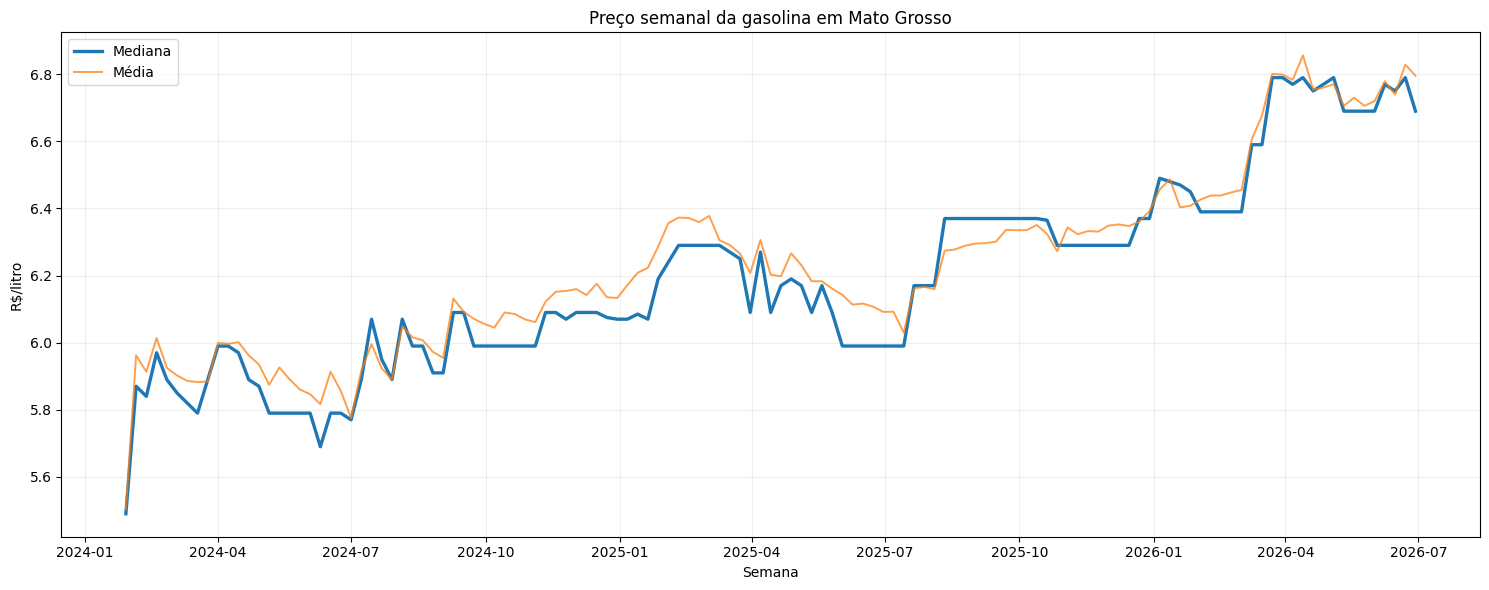

Salvo em: /content/mt_fuel_anomaly_ml/outputs/01_serie_preco_mt.png


In [12]:
# ============================================================
# 11. EVOLUÇÃO DO PREÇO MEDIANO EM MT
# ============================================================

serie_mt = (
    modelo_df
    .groupby("semana")["preco_venda"]
    .agg(["median", "mean"])
)

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    serie_mt.index,
    serie_mt["median"],
    label="Mediana",
    linewidth=2.4,
)

ax.plot(
    serie_mt.index,
    serie_mt["mean"],
    label="Média",
    linewidth=1.4,
    alpha=0.75,
)

ax.set_title(
    "Preço semanal da gasolina em Mato Grosso"
)
ax.set_xlabel("Semana")
ax.set_ylabel("R$/litro")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

arquivo = OUTPUT_DIR / "01_serie_preco_mt.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

print("Salvo em:", arquivo)

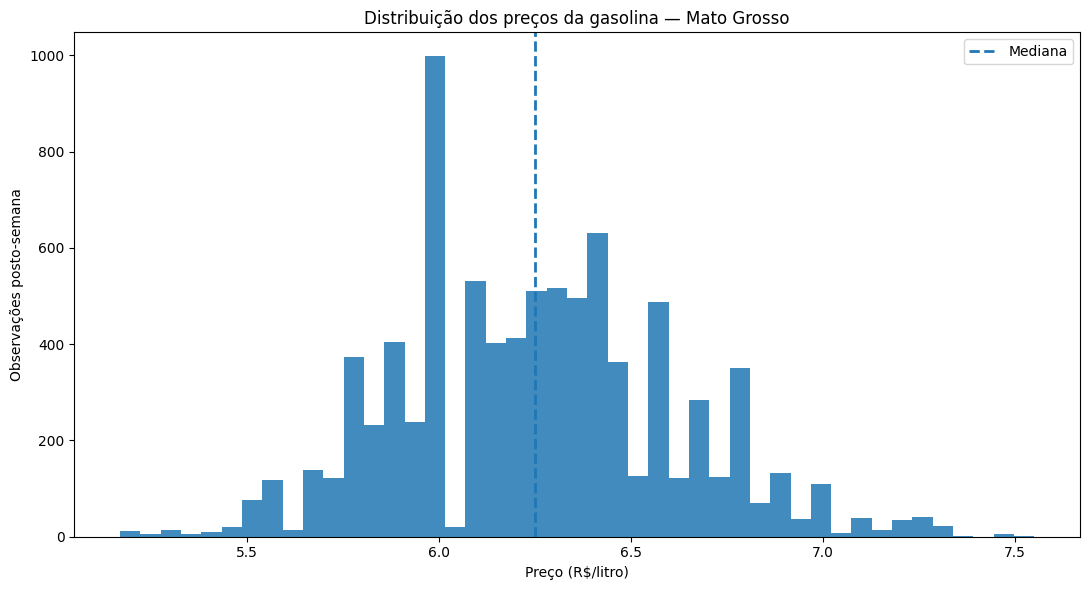

In [13]:
# ============================================================
# 12. DISTRIBUIÇÃO DOS PREÇOS
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    modelo_df["preco_venda"],
    bins=45,
    alpha=0.85,
)

ax.axvline(
    modelo_df["preco_venda"].median(),
    linestyle="--",
    linewidth=2,
    label="Mediana",
)

ax.set_title(
    "Distribuição dos preços da gasolina — Mato Grosso"
)
ax.set_xlabel("Preço (R$/litro)")
ax.set_ylabel("Observações posto-semana")
ax.legend()

plt.tight_layout()

arquivo = OUTPUT_DIR / "02_distribuicao_precos.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

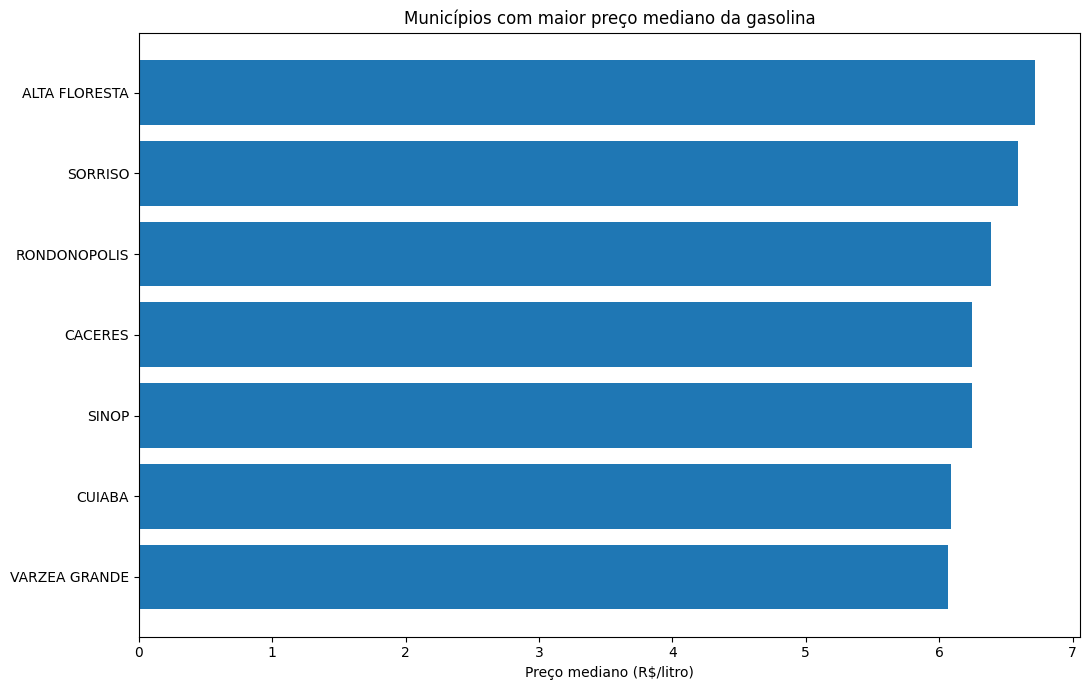

In [14]:
# ============================================================
# 13. MUNICÍPIOS COM MAIOR PREÇO MEDIANO
# ============================================================

ranking_preco = (
    modelo_df
    .groupby("municipio")
    .agg(
        preco_mediano=("preco_venda", "median"),
        observacoes=("preco_venda", "size"),
    )
    .query("observacoes >= 20")
    .sort_values("preco_mediano", ascending=False)
    .head(15)
    .sort_values("preco_mediano")
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    ranking_preco.index,
    ranking_preco["preco_mediano"],
)

ax.set_title(
    "Municípios com maior preço mediano da gasolina"
)
ax.set_xlabel("Preço mediano (R$/litro)")

plt.tight_layout()

arquivo = OUTPUT_DIR / "03_ranking_preco_municipios.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

# 7. Separação temporal e escalonamento

- **Treino:** 2024–2025
- **Teste real:** 2026

O `RobustScaler` é usado porque é menos sensível a valores extremos do que a padronização tradicional.

In [15]:
# ============================================================
# 14. TRAIN / TEST TEMPORAL
# ============================================================

train_df = modelo_df[
    modelo_df["semana"] < DATA_CORTE_TREINO
].copy()

test_df = modelo_df[
    modelo_df["semana"] >= DATA_CORTE_TREINO
].copy()

print("Treino:", len(train_df))
print("Teste:", len(test_df))

print(
    "Treino:",
    train_df["semana"].min(),
    "a",
    train_df["semana"].max(),
)

print(
    "Teste:",
    test_df["semana"].min(),
    "a",
    test_df["semana"].max(),
)

scaler = RobustScaler()

X_train = scaler.fit_transform(
    train_df[FEATURES]
)

X_test = scaler.transform(
    test_df[FEATURES]
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Treino: 6769
Teste: 1910
Treino: 2024-01-29 00:00:00 a 2025-12-29 00:00:00
Teste: 2026-01-05 00:00:00 a 2026-06-29 00:00:00
X_train: (6769, 15)
X_test: (1910, 15)


# 8. Modelo 1 — Isolation Forest

In [16]:
# ============================================================
# 15. ISOLATION FOREST
# ============================================================

iso = IsolationForest(
    n_estimators=500,
    contamination=CONTAMINATION,
    max_samples="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

iso.fit(X_train)

# Maior = mais anômalo.
score_if_test = -iso.decision_function(X_test)

print(
    "Score IF:",
    np.min(score_if_test),
    "a",
    np.max(score_if_test),
)

Score IF: -0.14650215638176828 a 0.07785482423381163


# 9. Modelo 2 — Local Outlier Factor

Usamos `novelty=True` para treinar no histórico e pontuar novas observações de 2026.

In [17]:
# ============================================================
# 16. LOCAL OUTLIER FACTOR
# ============================================================

lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination=CONTAMINATION,
    novelty=True,
    n_jobs=-1,
)

lof.fit(X_train)

score_lof_test = -lof.decision_function(X_test)

print(
    "Score LOF:",
    np.min(score_lof_test),
    "a",
    np.max(score_lof_test),
)

Score LOF: -0.5490849474008681 a 1.5788559097258614


# 10. Modelo 3 — One-Class SVM

One-Class SVM pode ficar pesado em bases grandes. Por isso treinamos com uma amostra representativa do histórico quando necessário.

In [18]:
# ============================================================
# 17. ONE-CLASS SVM
# ============================================================

MAX_TREINO_OCSVM = 25000

rng = np.random.default_rng(RANDOM_STATE)

if len(X_train) > MAX_TREINO_OCSVM:
    idx = rng.choice(
        len(X_train),
        MAX_TREINO_OCSVM,
        replace=False,
    )
    X_train_ocsvm = X_train[idx]
else:
    X_train_ocsvm = X_train

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=CONTAMINATION,
)

ocsvm.fit(X_train_ocsvm)

score_svm_test = -ocsvm.decision_function(X_test)

print(
    "Treino OCSVM:",
    X_train_ocsvm.shape
)

Treino OCSVM: (6769, 15)


# 11. Modelo 4 — Autoencoder

O Autoencoder aprende uma representação comprimida das observações históricas.

Se uma observação de 2026 é difícil de reconstruir, seu **erro de reconstrução** tende a ser maior.

In [19]:
# ============================================================
# 18. AUTOENCODER
# ============================================================

n_features = X_train.shape[1]

entrada = keras.Input(
    shape=(n_features,),
    name="input_features",
)

x = layers.Dense(
    32,
    activation="relu",
)(entrada)

x = layers.Dense(
    16,
    activation="relu",
)(x)

latent = layers.Dense(
    6,
    activation="relu",
    name="latent_space",
)(x)

x = layers.Dense(
    16,
    activation="relu",
)(latent)

x = layers.Dense(
    32,
    activation="relu",
)(x)

saida = layers.Dense(
    n_features,
    activation="linear",
)(x)

autoencoder = keras.Model(
    entrada,
    saida,
    name="fuel_anomaly_autoencoder",
)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
)

autoencoder.summary()

Model: "fuel_anomaly_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 6)              │           102 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,293 (8.96 KB)

 Trainable params: 2,293 (8.96 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ============================================================
# 19. TREINAMENTO DO AUTOENCODER
# ============================================================

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=5,
    factor=0.5,
    min_lr=1e-5,
)

history = autoencoder.fit(
    X_train,
    X_train,
    validation_split=0.20,
    epochs=150,
    batch_size=256,
    shuffle=True,
    callbacks=[
        early_stop,
        reduce_lr,
    ],
    verbose=1,
)

Epoch 1/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 1.8953 - val_loss: 2.6565 - learning_rate: 0.0010
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.7379 - val_loss: 2.2232 - learning_rate: 0.0010
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.3119 - val_loss: 1.5698 - learning_rate: 0.0010
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9195 - val_loss: 1.1092 - learning_rate: 0.0010
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6503 - val_loss: 0.6723 - learning_rate: 0.0010
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4483 - val_loss: 0.4326 - learning_rate: 0.0010
Epoch 7/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3456 - val_loss: 0.3512 - learning_rate: 0.0010
Epoch 8/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2954 - val_loss: 0.3107 - learning_rate: 0.0010
Epoch 9/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2660 - val_loss: 0.2882 - learning_rate: 0.0010
Epoch 10/15

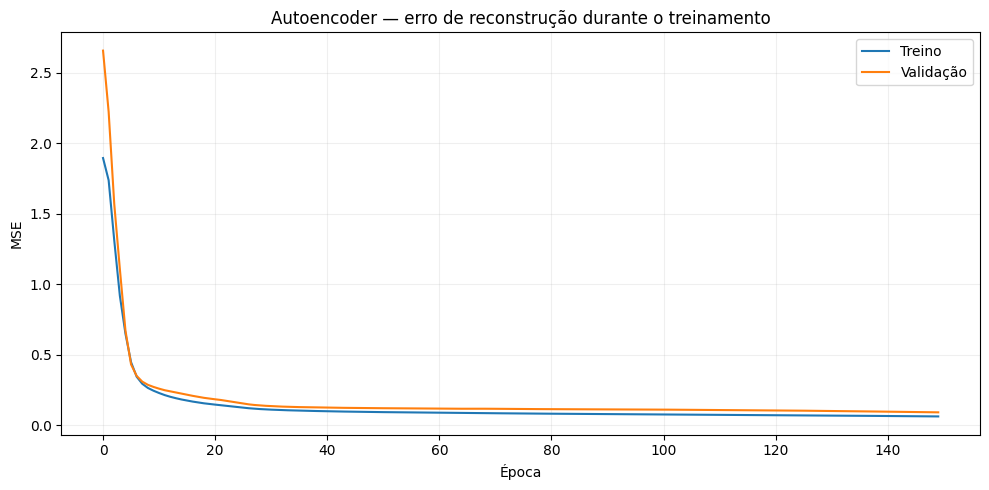

In [21]:
# ============================================================
# 20. CURVA DE TREINAMENTO DO AUTOENCODER
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    history.history["loss"],
    label="Treino",
)

ax.plot(
    history.history["val_loss"],
    label="Validação",
)

ax.set_title(
    "Autoencoder — erro de reconstrução durante o treinamento"
)
ax.set_xlabel("Época")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

arquivo = OUTPUT_DIR / "04_autoencoder_training.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

recon_test = autoencoder.predict(
    X_test,
    verbose=0,
)

score_ae_test = np.mean(
    np.square(X_test - recon_test),
    axis=1,
)

# 12. Scores comparáveis e Ensemble

Os quatro algoritmos produzem scores em escalas diferentes.

Transformamos cada score em um **percentil relativo ao comportamento do conjunto de treino**. Assim:

- próximo de 0 → comum;
- próximo de 1 → muito anômalo.

Depois calculamos a média dos quatro percentis.

In [22]:
# ============================================================
# 21. SCORES DE TREINO PARA CALIBRAÇÃO EMPÍRICA
# ============================================================

score_if_train = -iso.decision_function(X_train)

# Para LOF em novelty mode, a pontuação no próprio treino deve
# ser interpretada apenas como referência operacional.
score_lof_train = -lof.decision_function(X_train)

score_svm_train = -ocsvm.decision_function(X_train)

recon_train = autoencoder.predict(
    X_train,
    verbose=0,
)

score_ae_train = np.mean(
    np.square(X_train - recon_train),
    axis=1,
)


def score_percentil(score_train, score_novo):
    ref = np.sort(
        np.asarray(score_train)
    )

    return (
        np.searchsorted(
            ref,
            np.asarray(score_novo),
            side="right",
        )
        / len(ref)
    )


resultado = test_df.copy()

resultado["score_if"] = score_if_test
resultado["score_lof"] = score_lof_test
resultado["score_ocsvm"] = score_svm_test
resultado["score_ae"] = score_ae_test

resultado["pct_if"] = score_percentil(
    score_if_train,
    score_if_test,
)

resultado["pct_lof"] = score_percentil(
    score_lof_train,
    score_lof_test,
)

resultado["pct_ocsvm"] = score_percentil(
    score_svm_train,
    score_svm_test,
)

resultado["pct_ae"] = score_percentil(
    score_ae_train,
    score_ae_test,
)

resultado["ensemble_score"] = resultado[
    [
        "pct_if",
        "pct_lof",
        "pct_ocsvm",
        "pct_ae",
    ]
].mean(axis=1)

LIMIAR_ENSEMBLE = resultado[
    "ensemble_score"
].quantile(1 - CONTAMINATION)

resultado["anomalia_ensemble"] = (
    resultado["ensemble_score"]
    >= LIMIAR_ENSEMBLE
).astype(int)

print("Limiar ensemble:", LIMIAR_ENSEMBLE)
print(
    "Anomalias sinalizadas:",
    resultado["anomalia_ensemble"].sum(),
)

Limiar ensemble: 0.9866612498153345
Anomalias sinalizadas: 39


In [23]:
# ============================================================
# 22. TOP 30 ANOMALIAS DE 2026
# ============================================================

colunas_top = [
    "semana",
    "municipio",
    "revenda",
    "cnpj",
    "preco_venda",
    "mediana_municipio",
    "desvio_pct_municipio",
    "variacao_1s_pct",
    "z_historico_8s",
    "pct_if",
    "pct_lof",
    "pct_ocsvm",
    "pct_ae",
    "ensemble_score",
]

top_anomalias = (
    resultado
    .sort_values(
        "ensemble_score",
        ascending=False,
    )
    [colunas_top]
    .head(30)
)

display(top_anomalias)

,semana,municipio,revenda,cnpj,preco_venda,mediana_municipio,desvio_pct_municipio,variacao_1s_pct,z_historico_8s,pct_if,pct_lof,pct_ocsvm,pct_ae,ensemble_score
4588,2026-05-04,SINOP,J.D.COMERCIO DE COMBUSTIVEIS LTDA,06980032000187,6.99,6.89,1.451379,-1.410437,2.210133,0.999852,0.997341,0.999557,0.999409,0.999040
4589,2026-06-01,SINOP,J.D.COMERCIO DE COMBUSTIVEIS LTDA,06980032000187,6.59,6.89,-4.354136,-5.722461,0.706078,0.999261,0.997489,0.999409,0.999409,0.998892
4587,2026-03-23,SINOP,J.D.COMERCIO DE COMBUSTIVEIS LTDA,06980032000187,7.09,6.89,2.902758,18.36394,20.0,0.999852,0.999114,1.000000,0.996159,0.998781
4590,2026-06-22,SINOP,J.D.COMERCIO DE COMBUSTIVEIS LTDA,06980032000187,6.59,6.89,-4.354136,0.0,0.539247,0.997784,0.997932,0.998966,0.999705,0.998597
7241,2026-03-30,SINOP,BRAUNA COMERCIO DE COMBUSTIVEIS LTDA.,14309077000152,6.57,6.92,-5.057803,0.0,1.207615,0.999261,0.992022,0.998670,0.999557,0.997378
5939,2026-05-04,CUIABA,COMERCIAL AMAZONIA DE PETROLEO LTDA,09001879000675,6.31,6.77,-6.794682,-0.941915,0.958514,0.999705,0.996898,0.999261,0.993352,0.997304
1504,2026-05-04,SINOP,POSTO FELIX LTDA,02235792000109,6.59,6.89,-4.354136,0.0,2.457439,0.999114,0.994386,0.998818,0.995420,0.996935
7240,2026-03-23,SINOP,BRAUNA COMERCIO DE COMBUSTIVEIS LTDA.,14309077000152,6.57,6.89,-4.644412,0.0,1.620185,0.999409,0.989659,0.998670,0.998227,0.996491
7239,2026-03-16,SINOP,BRAUNA COMERCIO DE COMBUSTIVEIS LTDA.,14309077000152,6.57,6.79,-3.240059,0.0,2.467573,0.999114,0.991136,0.998670,0.996898,0.996454
4329,2026-04-06,SORRISO,COMÉRCIO DE COMBUSTÍVEIS LOURIE LTDA.,06047857000143,6.72,7.09,-5.218618,8.038585,14.259987,0.998523,0.993057,0.998966,0.994534,0.996270


# 13. Validação com anomalias sintéticas

A base real não informa quais preços são realmente anômalos.

Para comparar os algoritmos de forma controlada, alteramos uma pequena fração das observações de 2026 e **recalculamos todas as features**.

Tipos injetados:

- aumento abrupto;
- queda abrupta.

Essa validação não transforma anomalias reais desconhecidas em "normais"; ela serve como um **benchmark controlado de sensibilidade**.

In [24]:
# ============================================================
# 23. INJEÇÃO DE ANOMALIAS SINTÉTICAS
# ============================================================

def injetar_anomalias(
    base_original,
    data_inicio,
    fracao=0.035,
    seed=42,
):
    rng = np.random.default_rng(seed)

    sint = base_original.copy()

    elegiveis = sint.index[
        sint["semana"] >= data_inicio
    ].to_numpy()

    n = max(
        1,
        int(len(elegiveis) * fracao),
    )

    idx = rng.choice(
        elegiveis,
        size=n,
        replace=False,
    )

    metade = n // 2

    idx_alta = idx[:metade]
    idx_queda = idx[metade:]

    sint["anomalia_sintetica"] = 0
    sint["tipo_anomalia_sintetica"] = "normal"

    fator_alta = rng.uniform(
        1.18,
        1.38,
        size=len(idx_alta),
    )

    fator_queda = rng.uniform(
        0.68,
        0.85,
        size=len(idx_queda),
    )

    sint.loc[idx_alta, "preco_venda"] *= fator_alta
    sint.loc[idx_queda, "preco_venda"] *= fator_queda

    sint.loc[idx, "anomalia_sintetica"] = 1
    sint.loc[idx_alta, "tipo_anomalia_sintetica"] = "spike_up"
    sint.loc[idx_queda, "tipo_anomalia_sintetica"] = "spike_down"

    return sint


base_sint = injetar_anomalias(
    base,
    DATA_CORTE_TREINO,
    fracao=0.035,
    seed=RANDOM_STATE,
)

features_sint = criar_features(
    base_sint
)

features_sint = features_sint[
    features_sint["n_postos_municipio"]
    >= MIN_POSTOS_MUNICIPIO
].replace(
    [np.inf, -np.inf],
    np.nan,
)

features_sint = features_sint.dropna(
    subset=FEATURES
).reset_index(drop=True)

test_sint = features_sint[
    features_sint["semana"]
    >= DATA_CORTE_TREINO
].copy()

X_sint = scaler.transform(
    test_sint[FEATURES]
)

y_sint = (
    test_sint["anomalia_sintetica"]
    .astype(int)
    .to_numpy()
)

print(
    "Anomalias sintéticas no teste:",
    y_sint.sum(),
)

Anomalias sintéticas no teste: 66


In [25]:
# ============================================================
# 24. PONTUAÇÃO DOS MODELOS NO BENCHMARK SINTÉTICO
# ============================================================

s_if = -iso.decision_function(X_sint)
s_lof = -lof.decision_function(X_sint)
s_svm = -ocsvm.decision_function(X_sint)

rec_sint = autoencoder.predict(
    X_sint,
    verbose=0,
)

s_ae = np.mean(
    np.square(X_sint - rec_sint),
    axis=1,
)

p_if = score_percentil(
    score_if_train,
    s_if,
)

p_lof = score_percentil(
    score_lof_train,
    s_lof,
)

p_svm = score_percentil(
    score_svm_train,
    s_svm,
)

p_ae = score_percentil(
    score_ae_train,
    s_ae,
)

p_ensemble = np.column_stack(
    [p_if, p_lof, p_svm, p_ae]
).mean(axis=1)

In [26]:
# ============================================================
# 25. MÉTRICAS DE AVALIAÇÃO
# ============================================================

scores_modelos = {
    "Isolation Forest": p_if,
    "LOF": p_lof,
    "One-Class SVM": p_svm,
    "Autoencoder": p_ae,
    "Ensemble": p_ensemble,
}

linhas = []

for nome, score in scores_modelos.items():

    # Mesmo percentual de corte da contaminação escolhida.
    limiar = np.quantile(
        score,
        1 - CONTAMINATION,
    )

    pred = (
        score >= limiar
    ).astype(int)

    linhas.append(
        {
            "Modelo": nome,
            "ROC_AUC": roc_auc_score(
                y_sint,
                score,
            ),
            "PR_AUC": average_precision_score(
                y_sint,
                score,
            ),
            "Precision": precision_score(
                y_sint,
                pred,
                zero_division=0,
            ),
            "Recall": recall_score(
                y_sint,
                pred,
                zero_division=0,
            ),
            "F1": f1_score(
                y_sint,
                pred,
                zero_division=0,
            ),
        }
    )

metricas = (
    pd.DataFrame(linhas)
    .sort_values(
        "PR_AUC",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    metricas.style.format(
        {
            "ROC_AUC": "{:.3f}",
            "PR_AUC": "{:.3f}",
            "Precision": "{:.3f}",
            "Recall": "{:.3f}",
            "F1": "{:.3f}",
        }
    )
)

,Modelo,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Isolation Forest,0.997,0.896,0.959,0.712,0.817
1,Ensemble,0.995,0.837,0.804,0.561,0.661
2,One-Class SVM,0.948,0.257,0.257,1.000,0.409
3,LOF,0.947,0.251,0.252,0.985,0.401
4,Autoencoder,0.904,0.158,0.163,0.561,0.253


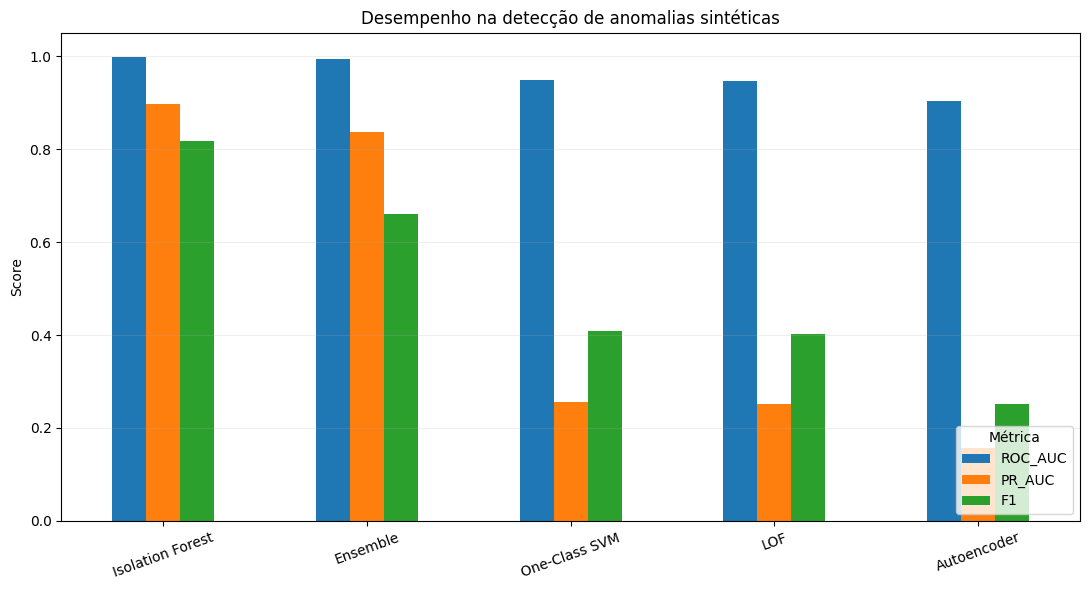

In [27]:
# ============================================================
# 26. GRÁFICO DE COMPARAÇÃO DOS MODELOS
# ============================================================

plot_metricas = metricas.set_index("Modelo")[
    ["ROC_AUC", "PR_AUC", "F1"]
]

fig, ax = plt.subplots(figsize=(11, 6))

plot_metricas.plot(
    kind="bar",
    ax=ax,
)

ax.set_ylim(0, 1.05)
ax.set_title(
    "Desempenho na detecção de anomalias sintéticas"
)
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend(
    title="Métrica",
    loc="lower right",
)
ax.grid(
    axis="y",
    alpha=0.2,
)

plt.xticks(rotation=20)
plt.tight_layout()

arquivo = OUTPUT_DIR / "05_model_comparison.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

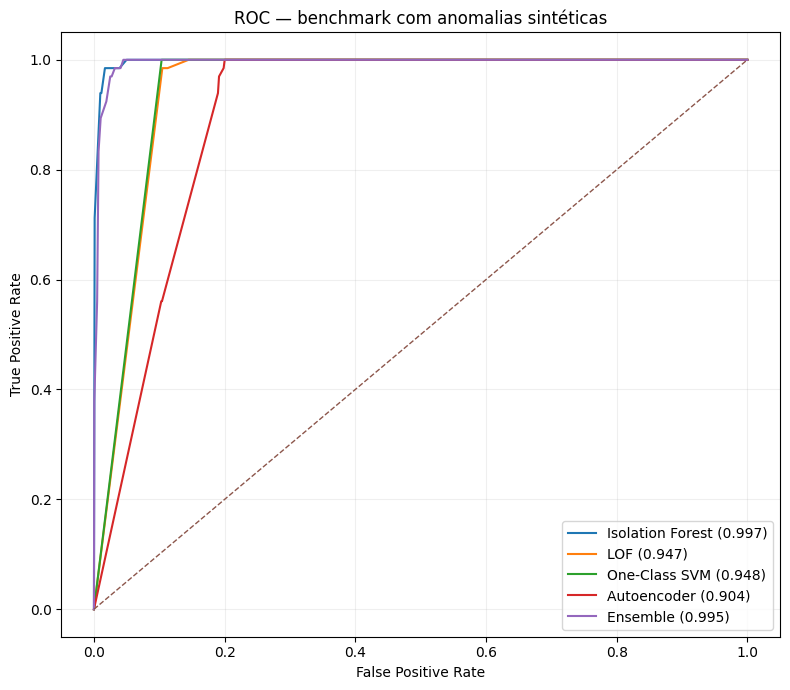

In [28]:
# ============================================================
# 27. CURVAS ROC
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

for nome, score in scores_modelos.items():
    fpr, tpr, _ = roc_curve(
        y_sint,
        score,
    )

    auc = roc_auc_score(
        y_sint,
        score,
    )

    ax.plot(
        fpr,
        tpr,
        label=f"{nome} ({auc:.3f})",
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "ROC — benchmark com anomalias sintéticas"
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

arquivo = OUTPUT_DIR / "06_roc_models.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

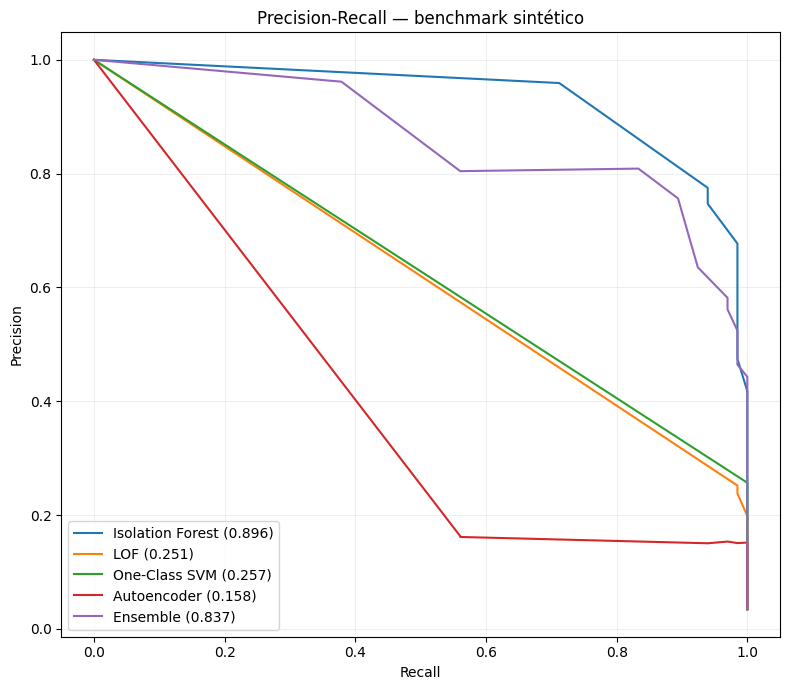

In [29]:
# ============================================================
# 28. CURVAS PRECISION-RECALL
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

for nome, score in scores_modelos.items():
    precision, recall, _ = precision_recall_curve(
        y_sint,
        score,
    )

    ap = average_precision_score(
        y_sint,
        score,
    )

    ax.plot(
        recall,
        precision,
        label=f"{nome} ({ap:.3f})",
    )

ax.set_title(
    "Precision-Recall — benchmark sintético"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

arquivo = OUTPUT_DIR / "07_precision_recall.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

# 14. Concordância entre os modelos

Um ponto especialmente interessante é identificar observações que são consideradas incomuns por vários métodos ao mesmo tempo.

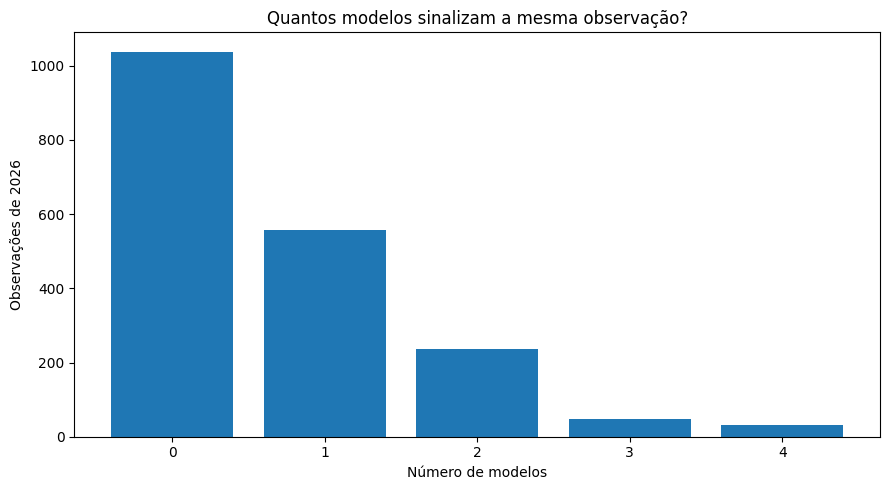

In [30]:
# ============================================================
# 29. CONCORDÂNCIA DOS MODELOS
# ============================================================

resultado["flag_if"] = (
    resultado["pct_if"] >= 1 - CONTAMINATION
).astype(int)

resultado["flag_lof"] = (
    resultado["pct_lof"] >= 1 - CONTAMINATION
).astype(int)

resultado["flag_ocsvm"] = (
    resultado["pct_ocsvm"] >= 1 - CONTAMINATION
).astype(int)

resultado["flag_ae"] = (
    resultado["pct_ae"] >= 1 - CONTAMINATION
).astype(int)

resultado["n_modelos_concordam"] = resultado[
    [
        "flag_if",
        "flag_lof",
        "flag_ocsvm",
        "flag_ae",
    ]
].sum(axis=1)

concordancia = (
    resultado["n_modelos_concordam"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    concordancia.index.astype(str),
    concordancia.values,
)

ax.set_title(
    "Quantos modelos sinalizam a mesma observação?"
)
ax.set_xlabel("Número de modelos")
ax.set_ylabel("Observações de 2026")

plt.tight_layout()

arquivo = OUTPUT_DIR / "08_model_agreement.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

# 15. PCA — visualizando o espaço de features

PCA é usado apenas para visualização.

Os modelos continuam sendo treinados no conjunto completo de features.

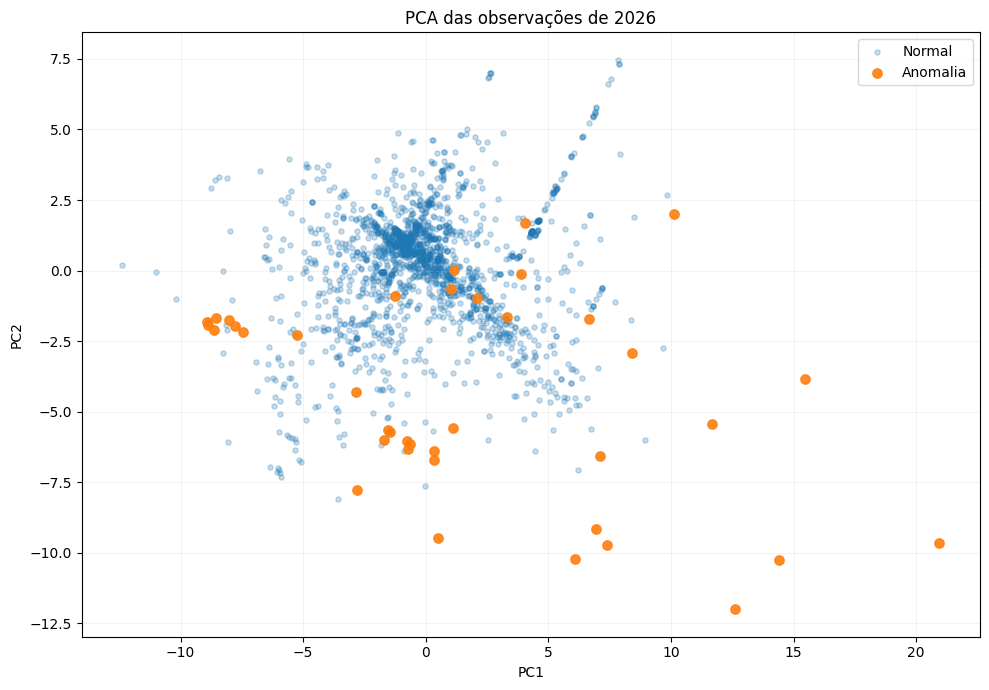

Variância explicada: 0.5963835220480428


In [31]:
# ============================================================
# 30. PCA 2D
# ============================================================

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

X_test_pca = pca.fit_transform(X_test)

pca_df = resultado[
    [
        "municipio",
        "semana",
        "ensemble_score",
        "anomalia_ensemble",
    ]
].copy()

pca_df["PC1"] = X_test_pca[:, 0]
pca_df["PC2"] = X_test_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))

normais = pca_df[
    pca_df["anomalia_ensemble"] == 0
]

anom = pca_df[
    pca_df["anomalia_ensemble"] == 1
]

ax.scatter(
    normais["PC1"],
    normais["PC2"],
    s=14,
    alpha=0.25,
    label="Normal",
)

ax.scatter(
    anom["PC1"],
    anom["PC2"],
    s=45,
    alpha=0.9,
    label="Anomalia",
)

ax.set_title(
    "PCA das observações de 2026"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
ax.grid(alpha=0.15)

plt.tight_layout()

arquivo = OUTPUT_DIR / "09_pca_anomalies.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

print(
    "Variância explicada:",
    pca.explained_variance_ratio_.sum(),
)

# 16. Download da malha municipal do IBGE

O mapa é obtido pelo próprio notebook. Não é necessário fazer upload manual de shapefile.

In [32]:
# ============================================================
# 31. DOWNLOAD DA MALHA DO IBGE
# ============================================================

ibge_zip = DATA_DIR / "MT_Municipios_2024.zip"
ibge_dir = DATA_DIR / "ibge_mt"

if not ibge_zip.exists():
    print("Baixando malha municipal do IBGE...")

    resp = requests.get(
        IBGE_MT_URL,
        timeout=180,
    )
    resp.raise_for_status()

    ibge_zip.write_bytes(
        resp.content
    )

ibge_dir.mkdir(
    parents=True,
    exist_ok=True,
)

with zipfile.ZipFile(
    ibge_zip
) as z:
    z.extractall(
        ibge_dir
    )

shps = list(
    ibge_dir.rglob("*.shp")
)

if not shps:
    raise FileNotFoundError(
        "Shapefile municipal não encontrado."
    )

mapa_mt = gpd.read_file(
    shps[0]
)

print(mapa_mt.columns.tolist())
display(mapa_mt.head())

Baixando malha municipal do IBGE...
['CD_MUN', 'NM_MUN', 'CD_RGI', 'NM_RGI', 'CD_RGINT', 'NM_RGINT', 'CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG', 'CD_CONCU', 'NM_CONCU', 'AREA_KM2', 'geometry']


,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
0,5106281,Novo São Joaquim,510013,Barra do Garças,5104,Barra do Garças,51,Mato Grosso,MT,5,Centro-oeste,CO,None,None,5225.595,"POLYGON ((-52.71726 -14.93292, -52.71741 -14.9..."
1,5106299,Paranaíta,510010,Alta Floresta,5103,Sinop,51,Mato Grosso,MT,5,Centro-oeste,CO,None,None,4814.149,"POLYGON ((-56.35358 -9.73451, -56.35358 -9.734..."
2,5104526,Ipiranga do Norte,510008,Sorriso,5103,Sinop,51,Mato Grosso,MT,5,Centro-oeste,CO,None,None,3422.016,"POLYGON ((-55.90644 -12.19491, -55.90683 -12.1..."
3,5103254,Colniza,510009,Juína,5103,Sinop,51,Mato Grosso,MT,5,Centro-oeste,CO,None,None,27960.237,"POLYGON ((-60.74345 -9.69861, -60.74345 -9.698..."
4,5104500,Indiavaí,510006,Mirassol D'oeste,5102,Cáceres,51,Mato Grosso,MT,5,Centro-oeste,CO,None,None,592.495,"POLYGON ((-58.64079 -15.39087, -58.64194 -15.3..."


In [33]:
# ============================================================
# 32. PREPARAÇÃO DOS NOMES MUNICIPAIS
# ============================================================

def normalizar_nome_municipio(txt):
    txt = sem_acento(txt).upper()
    txt = re.sub(r"[^A-Z0-9 ]+", " ", txt)
    txt = re.sub(r"\s+", " ", txt)
    return txt.strip()


candidatos_nome = [
    "NM_MUN",
    "NM_MUNICIP",
    "NM_MUNIC",
    "NM_MUNICIPIO",
]

COL_MUN_IBGE = next(
    (
        c for c in candidatos_nome
        if c in mapa_mt.columns
    ),
    None,
)

if COL_MUN_IBGE is None:
    raise KeyError(
        "Não foi possível identificar a coluna "
        "de nome do município no shapefile."
    )

mapa_mt["municipio_key"] = (
    mapa_mt[COL_MUN_IBGE]
    .map(normalizar_nome_municipio)
)

resultado["municipio_key"] = (
    resultado["municipio"]
    .map(normalizar_nome_municipio)
)

print("Coluna municipal do IBGE:", COL_MUN_IBGE)

Coluna municipal do IBGE: NM_MUN


# 17. Mapas

Produzimos dois mapas:

1. preço mediano municipal em 2026;
2. intensidade média do score de anomalia por município.

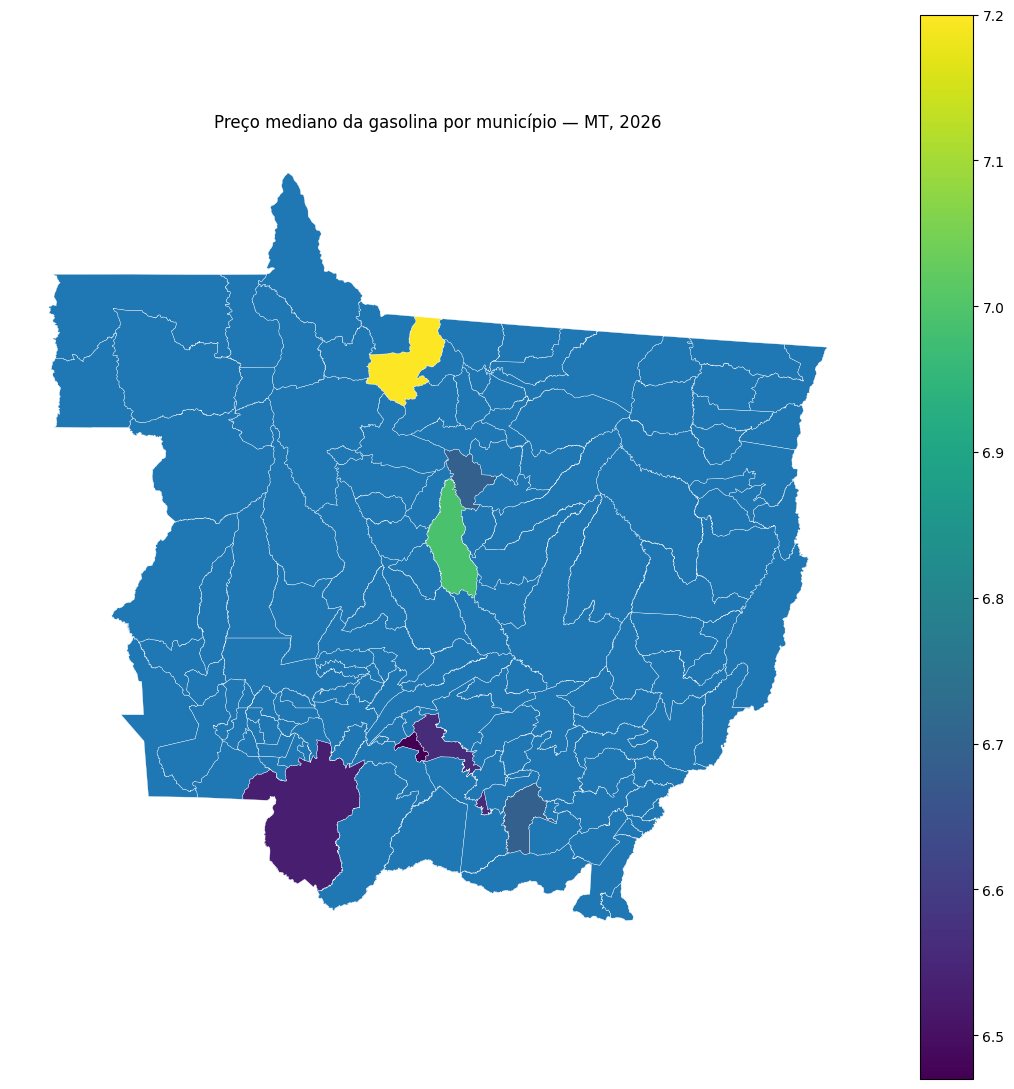

In [34]:
# ============================================================
# 33. MAPA — PREÇO MEDIANO MUNICIPAL
# ============================================================

preco_mun = (
    resultado
    .groupby(
        "municipio_key"
    )
    .agg(
        preco_mediano=("preco_venda", "median"),
        n_obs=("preco_venda", "size"),
    )
    .reset_index()
)

mapa_preco = mapa_mt.merge(
    preco_mun,
    on="municipio_key",
    how="left",
)

fig, ax = plt.subplots(
    figsize=(11, 11)
)

mapa_preco.plot(
    column="preco_mediano",
    legend=True,
    linewidth=0.25,
    edgecolor="white",
    missing_kwds={
        "label": "Sem observações",
    },
    ax=ax,
)

ax.set_title(
    "Preço mediano da gasolina por município — MT, 2026"
)
ax.axis("off")

plt.tight_layout()

arquivo = MAP_DIR / "mapa_preco_mediano_mt_2026.png"
plt.savefig(arquivo, dpi=200, bbox_inches="tight")
plt.show()

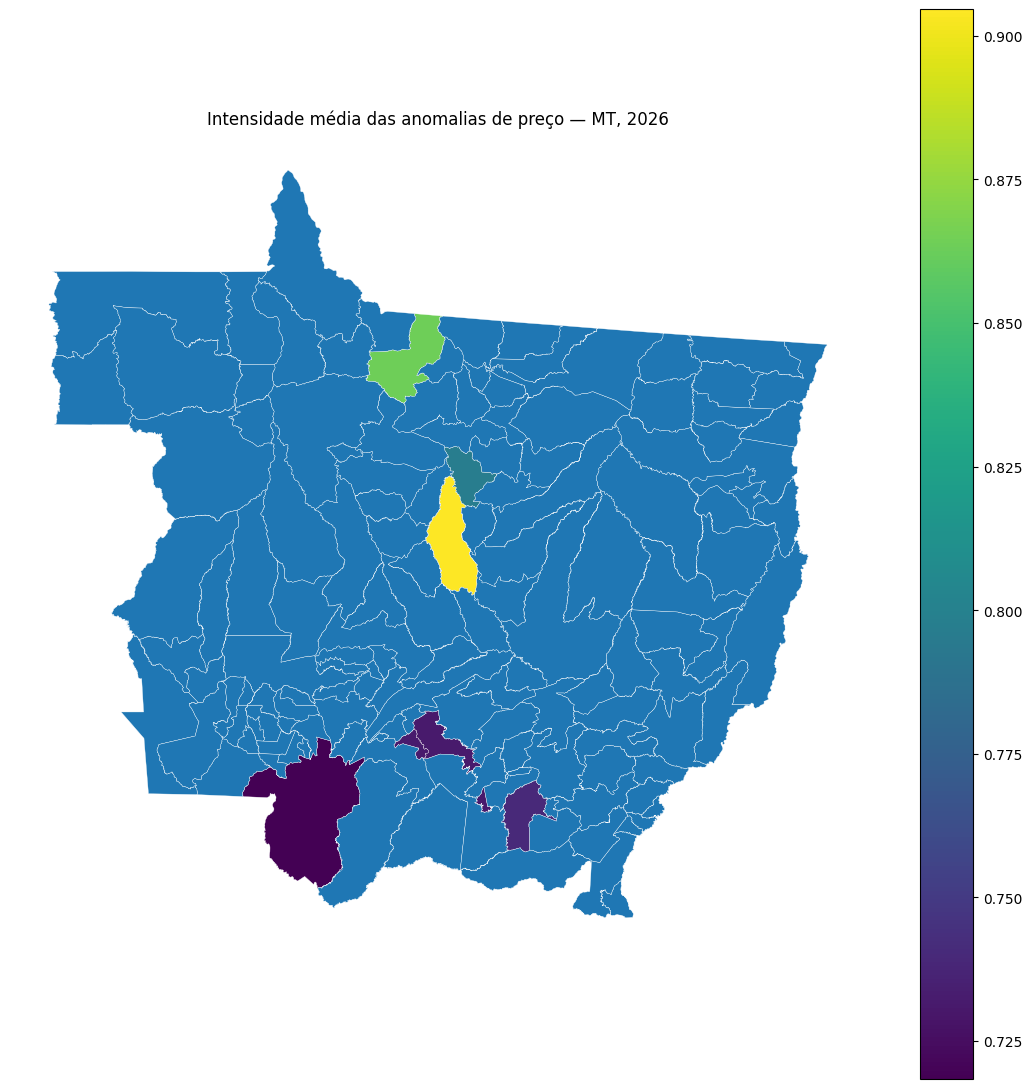

In [35]:
# ============================================================
# 34. MAPA — SCORE MÉDIO DE ANOMALIA
# ============================================================

anom_mun = (
    resultado
    .groupby(
        "municipio_key"
    )
    .agg(
        score_medio=("ensemble_score", "mean"),
        score_max=("ensemble_score", "max"),
        taxa_anomalia=("anomalia_ensemble", "mean"),
        n_obs=("ensemble_score", "size"),
    )
    .reset_index()
)

mapa_anom = mapa_mt.merge(
    anom_mun,
    on="municipio_key",
    how="left",
)

fig, ax = plt.subplots(
    figsize=(11, 11)
)

mapa_anom.plot(
    column="score_medio",
    legend=True,
    linewidth=0.25,
    edgecolor="white",
    missing_kwds={
        "label": "Sem observações",
    },
    ax=ax,
)

ax.set_title(
    "Intensidade média das anomalias de preço — MT, 2026"
)
ax.axis("off")

plt.tight_layout()

arquivo = MAP_DIR / "mapa_anomaly_score_mt_2026.png"
plt.savefig(arquivo, dpi=200, bbox_inches="tight")
plt.show()

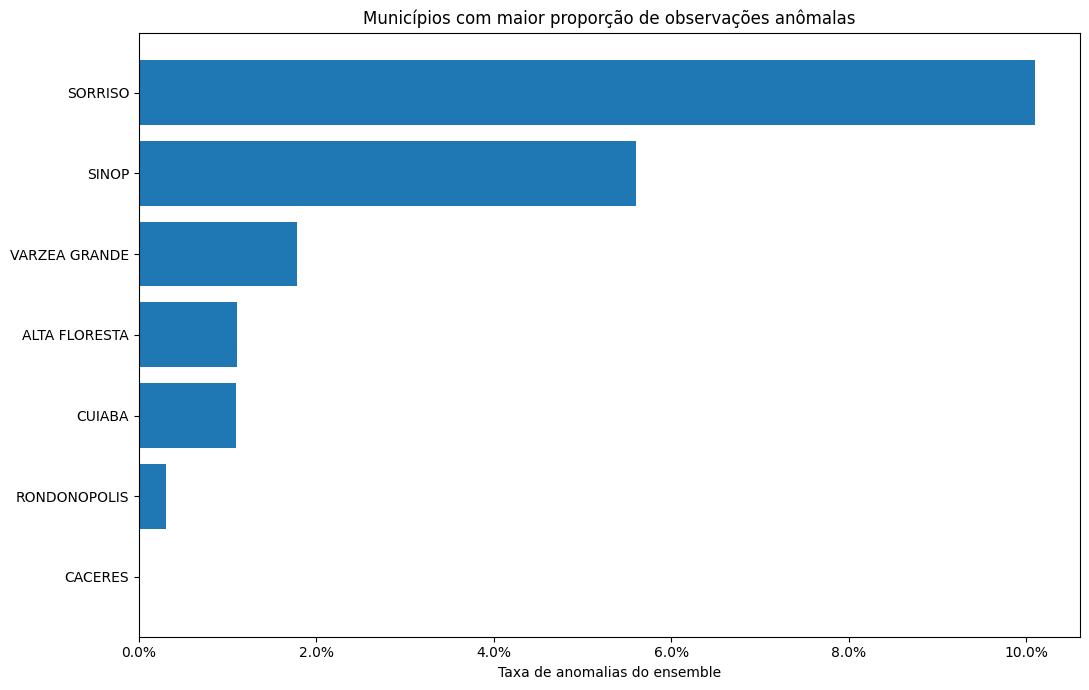

,municipio_key,taxa_anomalia,score_max,n_obs
5,SORRISO,0.101010,0.996270,99
4,SINOP,0.056000,0.999040,250
6,VARZEA GRANDE,0.017857,0.994534,392
0,ALTA FLORESTA,0.011111,0.992244,180
2,CUIABA,0.010965,0.997304,456
3,RONDONOPOLIS,0.003058,0.995162,327
1,CACERES,0.000000,0.981570,206


In [36]:
# ============================================================
# 35. RANKING DE MUNICÍPIOS POR TAXA DE ANOMALIA
# ============================================================

ranking_anom = (
    anom_mun
    .query("n_obs >= 15")
    .sort_values(
        "taxa_anomalia",
        ascending=False,
    )
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 7))

plot_rank = ranking_anom.sort_values(
    "taxa_anomalia"
)

ax.barh(
    plot_rank["municipio_key"],
    plot_rank["taxa_anomalia"],
)

ax.xaxis.set_major_formatter(
    PercentFormatter(1)
)

ax.set_title(
    "Municípios com maior proporção de observações anômalas"
)
ax.set_xlabel(
    "Taxa de anomalias do ensemble"
)

plt.tight_layout()

arquivo = OUTPUT_DIR / "10_ranking_municipios_anomalia.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

display(
    ranking_anom[
        [
            "municipio_key",
            "taxa_anomalia",
            "score_max",
            "n_obs",
        ]
    ]
)

# 18. Estudo de caso — posto com score extremo

Uma análise de portfólio fica muito mais forte quando mostra **casos concretos**, não apenas métricas agregadas.

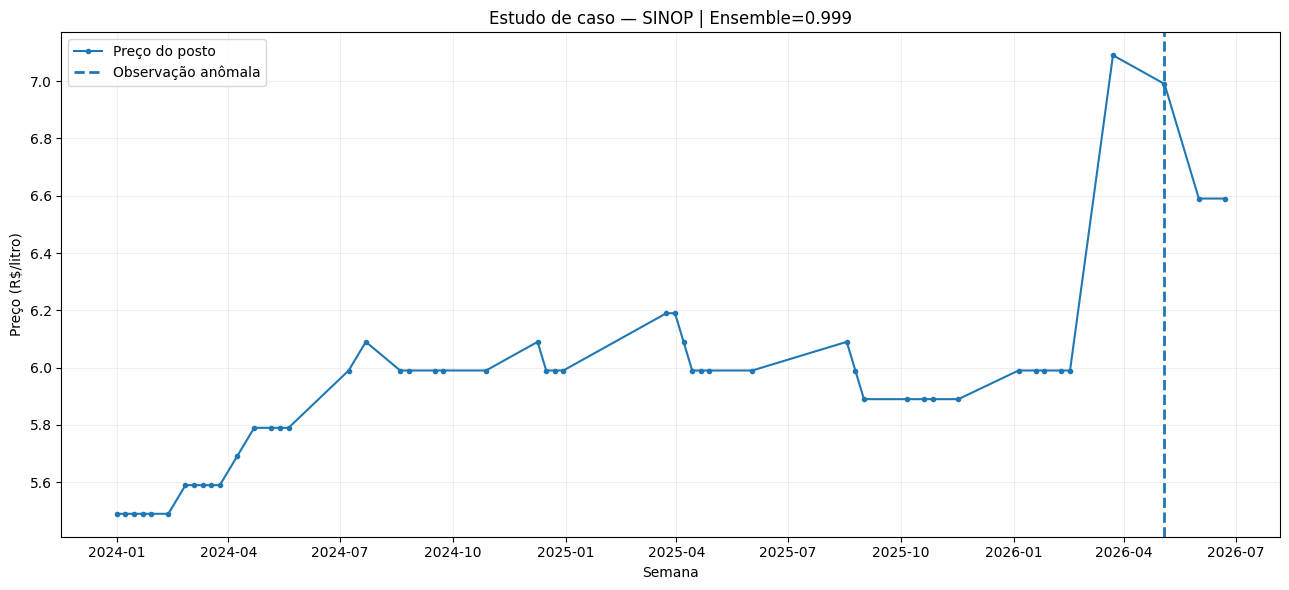

,Indicador,Valor
0,Município,SINOP
1,Posto,J.D.COMERCIO DE COMBUSTIVEIS LTDA
2,Preço,6.99
3,Mediana municipal,6.89
4,Desvio municipal (%),1.451379
5,Variação semanal (%),-1.410437
6,Z histórico,2.210133
7,Isolation Forest,0.999852
8,LOF,0.997341
9,One-Class SVM,0.999557


In [37]:
# ============================================================
# 36. ESTUDO DE CASO DO POSTO MAIS ANÔMALO
# ============================================================

caso = resultado.sort_values(
    "ensemble_score",
    ascending=False,
).iloc[0]

cnpj_caso = caso["cnpj"]
semana_caso = caso["semana"]

historico_caso = features_df[
    features_df["cnpj"] == cnpj_caso
].sort_values("semana")

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    historico_caso["semana"],
    historico_caso["preco_venda"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Preço do posto",
)

ax.axvline(
    semana_caso,
    linestyle="--",
    linewidth=2,
    label="Observação anômala",
)

ax.set_title(
    f"Estudo de caso — {caso['municipio']} | "
    f"Ensemble={caso['ensemble_score']:.3f}"
)
ax.set_xlabel("Semana")
ax.set_ylabel("Preço (R$/litro)")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

arquivo = OUTPUT_DIR / "11_case_study_top_station.png"
plt.savefig(arquivo, dpi=180, bbox_inches="tight")
plt.show()

display(
    pd.DataFrame(
        {
            "Indicador": [
                "Município",
                "Posto",
                "Preço",
                "Mediana municipal",
                "Desvio municipal (%)",
                "Variação semanal (%)",
                "Z histórico",
                "Isolation Forest",
                "LOF",
                "One-Class SVM",
                "Autoencoder",
                "Ensemble",
            ],
            "Valor": [
                caso["municipio"],
                caso["revenda"],
                caso["preco_venda"],
                caso["mediana_municipio"],
                caso["desvio_pct_municipio"],
                caso["variacao_1s_pct"],
                caso["z_historico_8s"],
                caso["pct_if"],
                caso["pct_lof"],
                caso["pct_ocsvm"],
                caso["pct_ae"],
                caso["ensemble_score"],
            ],
        }
    )
)

# 19. GIF — evolução semanal das anomalias por município

Esta célula cria automaticamente uma animação `.gif`.

Cada frame representa uma semana de 2026 e mostra a **média municipal do score do ensemble**.

Para manter o arquivo leve, usamos no máximo as últimas 18 semanas disponíveis.

In [38]:
# ============================================================
# 37. GIF DO MAPA DE ANOMALIAS
# ============================================================

gif_frames_dir = GIF_DIR / "frames"
gif_frames_dir.mkdir(
    parents=True,
    exist_ok=True,
)

semanas = sorted(
    resultado["semana"]
    .dropna()
    .unique()
)

semanas = semanas[-18:]

frames = []

for i, semana in enumerate(semanas):

    semana_ts = pd.Timestamp(semana)

    dados_semana = (
        resultado[
            resultado["semana"] == semana_ts
        ]
        .groupby(
            "municipio_key"
        )
        .agg(
            score=("ensemble_score", "mean"),
        )
        .reset_index()
    )

    mapa_semana = mapa_mt.merge(
        dados_semana,
        on="municipio_key",
        how="left",
    )

    fig, ax = plt.subplots(
        figsize=(8, 8)
    )

    mapa_semana.plot(
        column="score",
        vmin=0,
        vmax=1,
        legend=True,
        linewidth=0.20,
        edgecolor="white",
        ax=ax,
    )

    ax.set_title(
        "Anomaly score médio — Mato Grosso\n"
        + semana_ts.strftime("%d/%m/%Y")
    )
    ax.axis("off")

    frame_path = (
        gif_frames_dir
        / f"frame_{i:03d}.png"
    )

    plt.tight_layout()
    plt.savefig(
        frame_path,
        dpi=110,
        bbox_inches="tight",
    )
    plt.close(fig)

    frames.append(
        imageio.imread(frame_path)
    )

gif_path = (
    GIF_DIR
    / "mt_fuel_anomaly_evolution.gif"
)

imageio.mimsave(
    gif_path,
    frames,
    duration=0.75,
    loop=0,
)

print("GIF criado:", gif_path)

display(
    Image(
        filename=str(gif_path)
    )
)

ValueError: all input arrays must have the same shape

# 20. SHAP opcional — interpretando o Isolation Forest

Esta seção tenta explicar quais features mais influenciam a saída do Isolation Forest.

Ela é opcional porque versões diferentes do `shap` podem se comportar de forma diferente com detectores não supervisionados.

PermutationExplainer explainer: 401it [13:34,  2.04s/it]


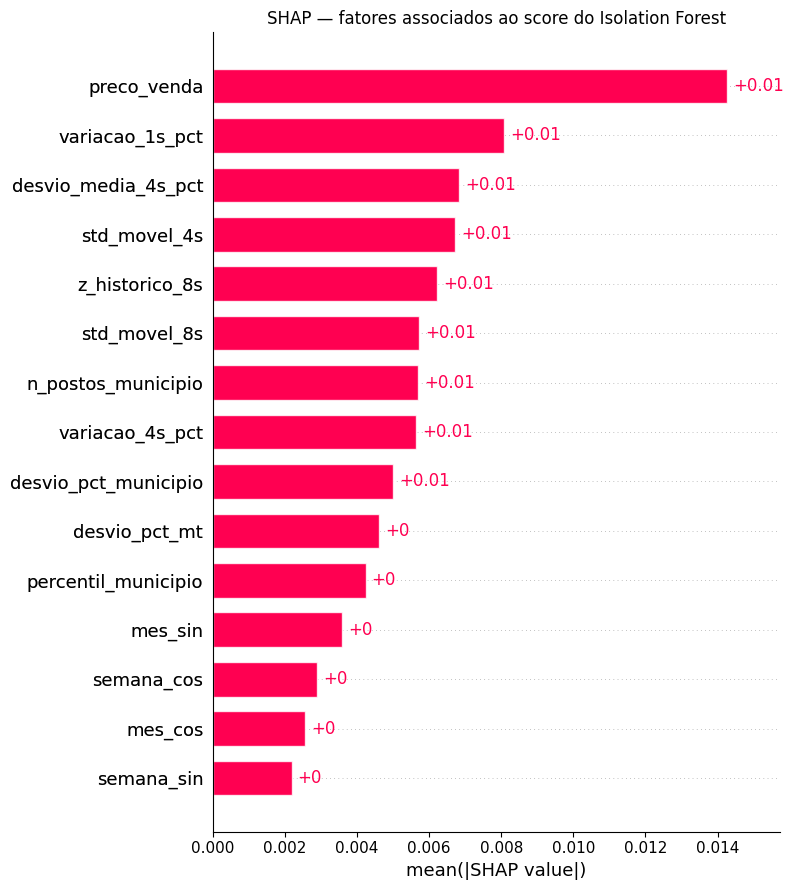

In [39]:
# ============================================================
# 38. SHAP OPCIONAL
# ============================================================

try:
    import shap

    n_background = min(
        500,
        len(X_train),
    )

    n_explain = min(
        400,
        len(X_test),
    )

    rng = np.random.default_rng(
        RANDOM_STATE
    )

    idx_bg = rng.choice(
        len(X_train),
        n_background,
        replace=False,
    )

    idx_exp = rng.choice(
        len(X_test),
        n_explain,
        replace=False,
    )

    background = X_train[idx_bg]
    explain_data = X_test[idx_exp]

    explainer = shap.Explainer(
        lambda z: -iso.decision_function(z),
        background,
        feature_names=FEATURES,
    )

    shap_values = explainer(
        explain_data
    )

    shap.plots.bar(
        shap_values,
        max_display=15,
        show=False,
    )

    plt.title(
        "SHAP — fatores associados ao score do Isolation Forest"
    )
    plt.tight_layout()

    arquivo = OUTPUT_DIR / "12_shap_isolation_forest.png"
    plt.savefig(
        arquivo,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

except Exception as exc:
    print(
        "SHAP não foi executado nesta versão do ambiente."
    )
    print("Motivo:", exc)

# 21. Resumo automático para README / LinkedIn

A célula abaixo cria um pequeno resumo factual dos resultados obtidos na execução.

In [40]:
# ============================================================
# 39. RESUMO AUTOMÁTICO
# ============================================================

top_mun = (
    resultado
    .groupby("municipio")
    .agg(
        score_medio=("ensemble_score", "mean"),
        taxa_anomalia=("anomalia_ensemble", "mean"),
        n=("ensemble_score", "size"),
    )
    .query("n >= 15")
    .sort_values(
        "taxa_anomalia",
        ascending=False,
    )
)

melhor_modelo = metricas.iloc[0]

print("=" * 72)
print("RESUMO DO PROJETO")
print("=" * 72)

print(
    f"Observações de treinamento: {len(train_df):,}"
)
print(
    f"Observações analisadas em 2026: {len(resultado):,}"
)
print(
    f"Postos em 2026: {resultado['cnpj'].nunique():,}"
)
print(
    f"Municípios em 2026: {resultado['municipio'].nunique():,}"
)

print(
    f"\nAnomalias sinalizadas pelo ensemble: "
    f"{resultado['anomalia_ensemble'].sum():,}"
)

print(
    f"Taxa sinalizada: "
    f"{resultado['anomalia_ensemble'].mean():.2%}"
)

print(
    f"\nMelhor modelo no benchmark sintético: "
    f"{melhor_modelo['Modelo']}"
)

print(
    f"PR-AUC: {melhor_modelo['PR_AUC']:.3f}"
)

print(
    f"ROC-AUC: {melhor_modelo['ROC_AUC']:.3f}"
)

if len(top_mun):
    print(
        f"\nMaior taxa municipal entre municípios elegíveis: "
        f"{top_mun.index[0]} "
        f"({top_mun.iloc[0]['taxa_anomalia']:.2%})"
    )

print("=" * 72)

RESUMO DO PROJETO
Observações de treinamento: 6,769
Observações analisadas em 2026: 1,910
Postos em 2026: 138
Municípios em 2026: 7

Anomalias sinalizadas pelo ensemble: 39
Taxa sinalizada: 2.04%

Melhor modelo no benchmark sintético: Isolation Forest
PR-AUC: 0.896
ROC-AUC: 0.997

Maior taxa municipal entre municípios elegíveis: SORRISO (10.10%)


In [41]:
# ============================================================
# 40. SALVAR RESULTADOS
# ============================================================

resultado_path = DATA_DIR / "mt_gasolina_anomalias_2026.parquet"
top_path = DATA_DIR / "top_anomalias_mt_2026.csv"
metricas_path = DATA_DIR / "model_metrics.csv"

resultado.to_parquet(
    resultado_path,
    index=False,
)

top_anomalias.to_csv(
    top_path,
    index=False,
    encoding="utf-8-sig",
)

metricas.to_csv(
    metricas_path,
    index=False,
    encoding="utf-8-sig",
)

print("Arquivos:")
print("-", resultado_path)
print("-", top_path)
print("-", metricas_path)
print("\nOutputs visuais:")
print("-", OUTPUT_DIR)

Arquivos:
- /content/mt_fuel_anomaly_ml/data/mt_gasolina_anomalias_2026.parquet
- /content/mt_fuel_anomaly_ml/data/top_anomalias_mt_2026.csv
- /content/mt_fuel_anomaly_ml/data/model_metrics.csv

Outputs visuais:
- /content/mt_fuel_anomaly_ml/outputs


# Conclusão metodológica

Este notebook trata o problema como **detecção não supervisionada de comportamento atípico**, e não como uma classificação de fraude.

O `ensemble_score` combina quatro perspectivas diferentes:

- **Isolation Forest:** isolamento global;
- **LOF:** densidade e vizinhança local;
- **One-Class SVM:** fronteira no espaço multivariado;
- **Autoencoder:** dificuldade de reconstrução.

O benchmark sintético permite comparar a sensibilidade dos modelos em um ambiente controlado, enquanto os mapas e estudos de caso ajudam a interpretar as anomalias reais sinalizadas em Mato Grosso.

## Próximas extensões possíveis

- incluir etanol e diesel;
- criar modelos específicos por município;
- acrescentar distância entre postos;
- incorporar preços de petróleo/câmbio;
- usar embeddings do Autoencoder como representação;
- construir dashboard Streamlit;
- transformar o pipeline em pacote Python;
- atualizar automaticamente com novos dados da ANP.